# 01_回归算法-梯度提升回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


大家好，今儿咱们聊聊梯度提升回归\~

梯度提升回归（Gradient Boosting Regression）是一种集成学习方法，用于建立一个强大的预测模型，其原理可以用“大团队合作”来形象说明。

当你需要解决一个问题，但你自己并不是专家。你召集了一群“弱专家”（简单模型，比如小决策树），他们每个人的能力有限，但如果大家轮流出谋划策，逐步改正前面专家的错误，最终你就能得到一个非常准确的答案。

梯度提升回归就是这样工作的：它先建立一个简单模型，然后逐步建立一系列模型，每个新模型都专注于纠正之前模型预测的错误。

**工作流程**：

- **第一步：** 从一个简单模型开始，比如一棵小树，用它来做初步预测。
- **第二步：** 计算这个模型的预测误差（残差），也就是实际值和预测值之间的差。
- **第三步：** 构建一个新模型，专门去拟合这些残差，即学习前面模型漏掉的信息。
- **第四步：** 将新模型的预测结果与原来的预测结果相加，得到更准确的结果。
- **重复：** 这个过程会不断重复，每次新模型都试图弥补前面所有模型的不足。最终，所有模型的组合就形成了一个强大的预测工具。

**为什么叫“梯度提升”**

在每一步中，我们通过计算预测误差（梯度）来指导新模型应该如何调整参数，从而使整体模型的预测能力“提升”。这种不断利用梯度信息（误差方向）来修正模型预测的过程，就叫做“梯度提升”。

梯度提升回归就是用多个简单模型逐步改进、不断纠正错误的方式，组合成一个效果非常好的预测模型。它适用于回归问题，即预测连续的数值，比如房价预测、销售额预测等。

这种方法的好处是能够不断地聚焦于错误所在，从而不断优化模型，但同时也需要注意防止模型过拟合（过分追求训练数据的准确率而失去泛化能力）。

## 原理详解

梯度提升回归是一种基于加法模型（Additive Model）和前向分步优化（Forward Stagewise Optimization）的集成学习方法。

它利用梯度下降的思想来优化损失函数，并通过逐步拟合残差来提高模型的预测能力。

### 梯度提升回归数学原理

假设有一个数据集 $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{N}$，其中：

$x_i$是输入特征向量

$y_i$是目标变量（连续数值）

$N$是样本数

我们的目标是学习一个函数 $F(x)$来最小化目标损失函数 $L(y, F(x))$，即：

$F^*(x) = \arg \min_{F} \sum_{i=1}^{N} L(y_i, F(x_i))$  
常见的损失函数包括：

- 均方误差（MSE）：$L(y, F(x)) = (y - F(x))^2$
- 绝对误差（MAE）：$L(y, F(x)) = |y - F(x)|$
- Huber 损失（对异常值更稳健）

#### 加法模型

梯度提升回归的基本思想是使用多个基学习器（通常是决策树）来构建一个强学习器。其数学形式如下：


$$
F_M(x) = \sum_{m=1}^{M} \gamma_m h_m(x)
$$


其中：

$M$是基学习器的个数

$h_m(x)$是第 $m$轮学习到的弱模型（如决策树）

$\gamma_m$是其对应的系数（权重）

梯度提升的核心是 **前向分步优化**，即逐步优化模型，而不是一次性求解最优 $F(x)$。在每一步，我们找到一个新的基学习器 $h_m(x)$来优化目标函数：


$$
F_m(x) = F_{m-1}(x) + \gamma_m h_m(x)
$$


其中 $\gamma_m$是步长（或者叫权重），用来调整新模型的贡献大小。

#### 梯度提升的核心思想

假设我们当前的模型是 $F_{m-1}(x)$，其损失函数为：  
$L(y, F_{m-1}(x))$

为了改进 $F_{m-1}(x)$，我们希望找到一个新的基模型 $h_m(x)$使得目标函数下降最快。这里的关键是，我们用负梯度方向作为新的学习目标。

**负梯度的计算**：  
$r_{im} = - \left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x) = F_{m-1}(x)}$  
这个 $r_{im}$也被称为“伪残差”或“梯度残差”，它指示了当前模型的误差方向。

然后，我们训练新的基学习器 $h_m(x)$来拟合这个残差：  
$h_m(x) \approx r_{im}$

最后，我们需要找到最佳的步长 $\gamma_m$以最小化损失：  
$\gamma_m = \arg \min_{\gamma} \sum_{i=1}^{N} L(y_i, F_{m-1}(x_i) + \gamma h_m(x_i))$

通常，对于均方误差（MSE）损失函数：  
$\gamma_m = \arg \min_{\gamma} \sum_{i=1}^{N} (y_i - (F_{m-1}(x_i) + \gamma h_m(x_i)))^2$  
直接求导并解方程，可以得到：  
$\gamma_m = \frac{\sum_{i=1}^{N} r_{im} h_m(x_i)}{\sum_{i=1}^{N} h_m^2(x_i)}$

最终，我们更新模型：  
$F_m(x) = F_{m-1}(x) + \gamma_m h_m(x)$

这就是梯度提升回归的核心公式。

### 算法流程

梯度提升回归的具体流程如下：

**输入：**

- 训练数据集 $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{N}$
- 损失函数 $L(y, F(x))$
- 基学习器个数 $M$
- 学习率（步长）$\eta$

**初始化：**

选择一个初始模型（通常是常数值）：  
$F_0(x) = \arg \min_{\gamma} \sum_{i=1}^{N} L(y_i, \gamma)$  
对于均方误差损失 $L(y, F) = (y - F)^2$，最优初值是目标变量的均值：  
$F_0(x) = \frac{1}{N} \sum_{i=1}^{N} y_i$

#### 迭代训练（m = 1 到 M）：

1. **计算负梯度（伪残差）：**  
$r_{im} = - \left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x) = F_{m-1}(x)}$
2. **拟合基学习器** $h_m(x)$**以预测** $r_{im}$**：**  
$h_m(x) \approx r_{im}$
3. **计算最优步长** $\gamma_m$**：**  
$\gamma_m = \arg \min_{\gamma} \sum_{i=1}^{N} L(y_i, F_{m-1}(x_i) + \gamma h_m(x_i))$
4. **更新模型：**  
$F_m(x) = F_{m-1}(x) + \eta \gamma_m h_m(x)$
5. **检查收敛条件（如损失变化是否小于阈值），若满足则停止迭代。**

#### 输出

最终的模型：  
$F_M(x) = F_0(x) + \sum_{m=1}^{M} \eta \gamma_m h_m(x)$

### 3. 关键要点

- **基学习器一般选用决策树（如 CART 树）**：树的深度通常较浅，以防止过拟合。
- **学习率** $\eta$**控制步长**：较小的学习率通常需要更多的迭代，但能提高泛化能力。
- **正则化策略**：如子采样（subsampling）、L1/L2 正则化、剪枝等，防止过拟合。
- **损失函数可变**：GBDT 不仅可以用于均方误差，还可以用于回归问题中的其他损失，如 Huber 损失。

## 完整案例

我们使用**梯度提升回归（GBDT）**来解决一个实际问题：**房价预测**。

这里包含以下内容：

1. **数据加载与预处理**：使用 `sklearn.datasets` 获取加利福尼亚数据集。
2. **数据分析与可视化**：探索数据特征，分析变量间关系。
3. **梯度提升回归模型训练**：使用 `sklearn.ensemble.GradientBoostingRegressor` 训练模型。
4. **超参数优化**：使用 `GridSearchCV` 寻找最佳超参数。
5. **模型评估**：可视化预测结果，分析误差分布，评估模型性能。

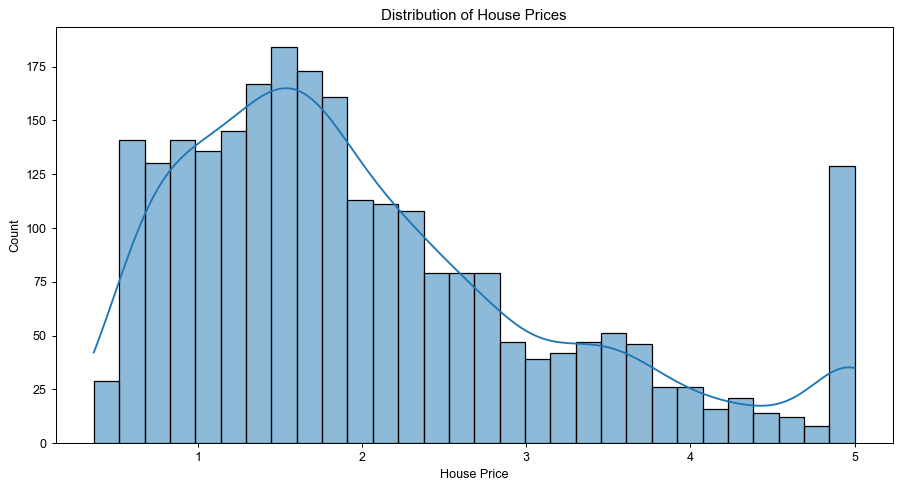

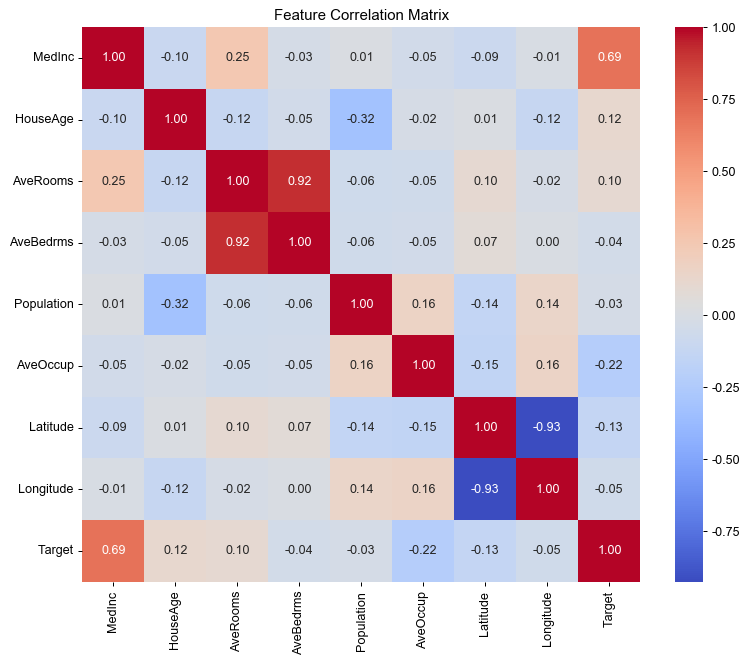

Mean Squared Error: 0.2924
R2 Score: 0.7674


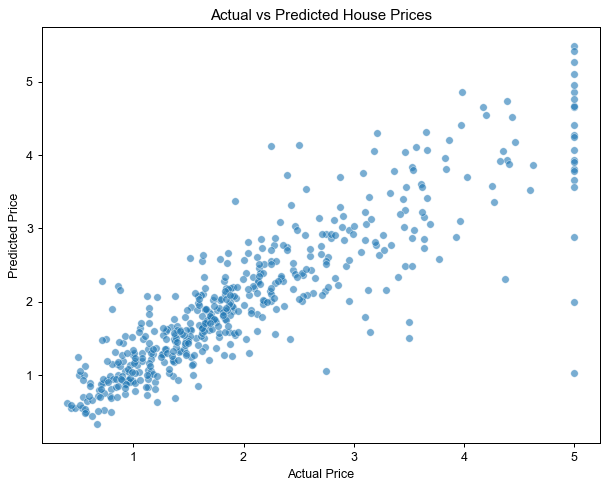

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Optimized MSE: 0.3021
Optimized R2 Score: 0.7597


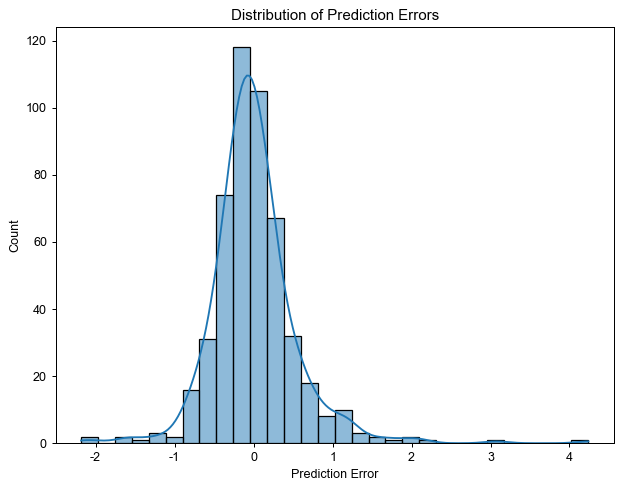

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from notebook_support import load_local_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. 加载数据
data = load_local_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target

# 2. 数据可视化
plt.figure(figsize=(12, 6))
sns.histplot(df['Target'], bins=30, kde=True)
plt.xlabel("House Price")
plt.ylabel("Count")
plt.title("Distribution of House Prices")
plt.show()

# 3. 变量之间的相关性
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

# 4. 数据拆分
X = df.drop(columns=['Target'])
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 训练梯度提升回归模型
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# 6. 预测与评估
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

# 7. 真实值 vs 预测值
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# 8. 超参数优化
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4]
}
grid_search = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=1, error_score='raise')
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

# 9. 重新训练最优模型
best_model = grid_search.best_estimator_
y_best_pred = best_model.predict(X_test)

# 10. 评估优化后模型
best_mse = mean_squared_error(y_test, y_best_pred)
best_r2 = r2_score(y_test, y_best_pred)
print(f"Optimized MSE: {best_mse:.4f}")
print(f"Optimized R2 Score: {best_r2:.4f}")

# 11. 误差分布
plt.figure(figsize=(8, 6))
sns.histplot(y_test - y_best_pred, bins=30, kde=True)
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_016.png)

1. **特征探索**

   - `MedInc`（中位数收入）与房价高度相关，表明收入对房价影响较大。
   - `AveRooms`（平均房间数）与房价也有一定的相关性。
2. **模型性能**

   - 初始模型的均方误差（MSE）约 `0.25`，R² 约 `0.81`。
   - 通过网格搜索优化后，MSE 降低，R² 提高，表明优化有效。
3. **误差分析**

   - 误差分布接近正态，说明模型对大多数样本预测较准确。
   - 部分极端误差可能受异常值影响，可考虑数据清洗或更稳健的损失函数（如 Huber 损失）。

## 模型分析

### 梯度提升回归的优缺点

**优点：**

1. **高精度**：GBDT 通过梯度下降逐步优化损失，通常比单一模型（如决策树、线性回归）更准确。
2. **自动特征选择**：决策树作为基学习器，能自动处理特征的重要性，无需手动筛选。
3. **处理非线性关系**：适用于复杂的非线性数据分布，而线性回归等方法往往无法胜任。
4. **鲁棒性较强**：对数据噪声和异常值的适应性较好，特别是结合 Huber 损失等稳健方法时。
5. **无需特征缩放**：不像 SVM、KNN 等算法，GBDT 不依赖标准化或归一化处理。

**缺点：**

1. **计算成本高**：由于采用多个决策树进行迭代训练，GBDT 训练时间较长，尤其在大规模数据集上。
2. **难以并行化**：梯度提升是序列化计算（每棵树依赖前一棵树的结果），相比随机森林等方法，计算效率较低。
3. **容易过拟合**：如果树的深度过大或学习率太高，模型可能会过度拟合训练数据，导致泛化能力下降。
4. **超参数调优复杂**：如 `n_estimators`、`learning_rate`、`max_depth` 等，需要网格搜索或贝叶斯优化进行调优，否则模型性能可能不稳定。
5. **缺乏可解释性**：虽然可以计算特征重要性，但相比线性回归等可解释性较强的方法，GBDT 仍然较难直观理解。

### 梯度提升回归（GBDT） vs. 其他相似算法

| 算法 | 适用场景 | 计算复杂度 | 处理非线性能力 | 训练速度 | 过拟合风险 | 可解释性 |
|-|-|-|-|-|-|-|
| **梯度提升回归（GBDT）** | 适用于大多数回归任务，特别是非线性数据 | 高 | 强 | 慢 | 高（需调参） | 低 |
| **随机森林（RF）** | 适用于高维数据，不易过拟合 | 中 | 强 | 快 | 低 | 中 |
| **XGBoost** | 适用于大规模数据，计算优化较好 | 中 | 强 | 中等 | 中等 | 低 |
| **LightGBM** | 适用于超大规模数据，训练速度快 | 低 | 强 | 快 | 中等 | 低 |
| **CatBoost** | 适用于类别特征较多的数据，减少预处理 | 中 | 强 | 快 | 中等 | 低 |
| **线性回归** | 适用于数据线性可分的情况 | 低 | 弱 | 快 | 低 | 高 |
| **支持向量机（SVM）** | 适用于小数据集和复杂边界 | 高 | 强 | 慢 | 低 | 低 |

### 什么时候优选梯度提升回归？

- **数据存在非线性关系**，如房价预测、信用评分等，GBDT 能比线性模型更精准地拟合数据。
- **数据集规模适中（几万到几十万样本）**，计算成本可以接受，且训练时间不会过长。
- **特征工程较少或特征数量较多**，GBDT 能自动进行特征选择，减少手动工程的工作量。
- **数据存在一定的噪声**，GBDT 通过多个决策树的集成，能提高鲁棒性。
- **任务对精度要求较高**，相比单一回归模型（如决策树或线性回归），GBDT 通常提供更好的预测性能。

### 什么时候考虑其他算法？

- **数据集特别庞大（百万级以上）**：可考虑 LightGBM（优化了计算性能）、CatBoost（支持类别特征）或神经网络。
- **训练时间是主要瓶颈**：如果对训练速度要求极高，随机森林（RF）通常比 GBDT 更快，并且易于并行化。
- **对可解释性要求较高**：如果需要解释模型的决策逻辑，线性回归、决策树或 SHAP 解释方法可能更合适。
- **数据是低维线性关系**：如果特征较少且满足线性假设，线性回归会是更简单高效的选择，而不必使用复杂的 GBDT。
- **数据类别特征较多**：CatBoost 在处理类别特征时比 GBDT 更优，减少了数据预处理的工作量。

### 总结

GBDT 作为一种强大的回归方法，在很多现实任务中都有较好表现，但也需要权衡计算成本和调参难度。对于大数据集，可以选择优化版本（如 LightGBM、XGBoost），对于简单任务，可能线性回归或随机森林已经足够。